In [ ]:

import os
import rawpy
import numpy as np
import cv2
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error, accuracy_score
from scipy import stats
import joblib
from tqdm import tqdm
import torch
from torchvision.models import Inception_V3_Weights, inception_v3
import torchvision.transforms as transforms
import pandas as pd


cr3_folder = r"C:\Users\charl\OneDrive\Desktop\4442\all"
output_dir = os.path.dirname(cr3_folder)
category_names = ["animal", "building", "flight", "mountain", "view"]


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = Inception_V3_Weights.DEFAULT
inception = inception_v3(weights=weights, aux_logits=True).to(device)
inception.fc = torch.nn.Identity()
inception.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


def load_cr3_image_as_rgb(path):
    with rawpy.imread(path) as raw:
        return raw.postprocess()

def extract_features(img_np):
    tensor = transform(img_np).unsqueeze(0).to(device)
    with torch.no_grad():
        features = inception(tensor)
    return features.squeeze().cpu().numpy()


X, y = [], []
for image_id in tqdm(range(1, 126), desc="提取图像特征"):
    path = os.path.join(cr3_folder, f"{image_id}.cr3")
    try:
        img = load_cr3_image_as_rgb(path)
        feat = extract_features(img)
        X.append(feat)
        y.append(category_names[(image_id - 1) // 25])
    except Exception as e:
        print(f"[跳过] {path}: {e}")

X = np.array(X)
y = np.array(y)
le = LabelEncoder()
y_encoded = le.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("\n✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


def compute_ci(data, confidence=0.95):
    boot = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(1000)]
    return np.percentile(boot, [2.5, 97.5])

print("\n🔍 开始五折交叉验证评估...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs = cross_val_predict(svm, X, y_encoded, cv=cv, method="predict_proba")
y_preds = np.argmax(y_probs, axis=1)

acc = accuracy_score(y_encoded, y_preds)
mse = mean_squared_error(y_encoded, y_preds)
roc_auc = roc_auc_score(y_encoded, y_probs, multi_class='ovo')
acc_ci = compute_ci((y_preds == y_encoded).astype(int))

print(f"\n✅ 5折交叉验证：")
print(f"- Accuracy: {acc:.4f} (95% CI: {acc_ci[0]:.4f} ~ {acc_ci[1]:.4f})")
print(f"- MSE: {mse:.4f}")
print(f"- ROC AUC (OVO): {roc_auc:.4f}")


joblib.dump(svm, os.path.join(output_dir, "svm_model_cnn.pkl"))
joblib.dump(le, os.path.join(output_dir, "label_encoder_cnn.pkl"))
print("\n✅ 模型与标签编码器已保存。")


提取图像特征: 100%|██████████| 125/125 [02:15<00:00,  1.09s/it]



✅ Test Accuracy: 0.96

Classification Report:
               precision    recall  f1-score   support

      animal       0.83      1.00      0.91         5
    building       1.00      1.00      1.00         5
      flight       1.00      1.00      1.00         5
    mountain       1.00      1.00      1.00         5
        view       1.00      0.80      0.89         5

    accuracy                           0.96        25
   macro avg       0.97      0.96      0.96        25
weighted avg       0.97      0.96      0.96        25

Confusion Matrix:
 [[5 0 0 0 0]
 [0 5 0 0 0]
 [0 0 5 0 0]
 [0 0 0 5 0]
 [1 0 0 0 4]]

🔍 开始五折交叉验证评估...

✅ 5折交叉验证：
- Accuracy: 0.9760 (95% CI: 0.9440 ~ 1.0000)
- MSE: 0.1440
- ROC AUC (OVO): 0.9996

✅ 模型与标签编码器已保存。


In [ ]:
import os
import rawpy
import numpy as np
import pandas as pd
from PIL import Image
import imageio.v2 as imageio
import joblib
from tqdm import tqdm

import torch
import torchvision.transforms as transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, mean_squared_error, accuracy_score
from scipy import stats


test_folder = r"C:\Users\charl\OneDrive\Desktop\4442\test"
model_path = r"C:\Users\charl\OneDrive\Desktop\4442\svm_model_cnn.pkl"
label_encoder_path = r"C:\Users\charl\OneDrive\Desktop\4442\label_encoder_cnn.pkl"


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


weights = Inception_V3_Weights.DEFAULT
inception = inception_v3(weights=weights, aux_logits=True).to(device)
inception.fc = torch.nn.Identity()
inception.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


def load_image(path):
    ext = os.path.splitext(path)[-1].lower()
    if ext == ".cr3":
        with rawpy.imread(path) as raw:
            img = raw.postprocess()
    else:
        img = imageio.imread(path)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.shape[2] == 4:
            img = img[:, :, :3]
        if img.dtype == np.uint16:
            img = (img / 256).astype(np.uint8)
        elif img.dtype in [np.float32, np.float64]:
            img = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img


def extract_feature(img_np):
    tensor = transform(img_np).unsqueeze(0).to(device)
    with torch.no_grad():
        features = inception(tensor)
    return features.squeeze().cpu().numpy()


svm = joblib.load(model_path)
le = joblib.load(label_encoder_path)


results = []

for file in tqdm(os.listdir(test_folder), desc="预测中"):
    file_path = os.path.join(test_folder, file)
    try:
        img = load_image(file_path)
        feat = extract_feature(img)
        pred = svm.predict([feat])[0]
        prob = np.max(svm.predict_proba([feat]))
        results.append({
            "filename": file,
            "predicted_category": le.inverse_transform([pred])[0],
            "confidence": round(prob * 100, 2)
        })
    except Exception as e:
        print(f"[跳过] 无法处理文件 {file}: {e}")


df = pd.DataFrame(results)
output_csv = os.path.join(test_folder, "svm_test_results.csv")
df.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ 测试完成，结果保存至: {output_csv}")



print("\n🔍 开始五折交叉验证评估...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_probs = cross_val_predict(svm, X, y_encoded, cv=cv, method="predict_proba")
y_preds = np.argmax(y_probs, axis=1)


acc = accuracy_score(y_encoded, y_preds)


mse = mean_squared_error(y_encoded, y_preds)


try:
    roc_auc = roc_auc_score(y_encoded, y_probs, multi_class='ovo')
except:
    roc_auc = np.nan


def compute_ci(data, confidence=0.95):
    boot = []
    n = len(data)
    for _ in range(1000):
        sample = np.random.choice(data, size=n, replace=True)
        boot.append(np.mean(sample))
    lower = np.percentile(boot, (1 - confidence) / 2 * 100)
    upper = np.percentile(boot, (1 + confidence) / 2 * 100)
    return lower, upper


acc_ci = compute_ci((y_preds == y_encoded).astype(int))

# 输出结果
print(f"\n✅ 5折交叉验证结果：")
print(f"- Accuracy: {acc:.4f} (95% CI: {acc_ci[0]:.4f} ~ {acc_ci[1]:.4f})")
print(f"- MSE: {mse:.4f}")
print(f"- ROC AUC (OVO): {roc_auc:.4f}")


预测中: 100%|██████████| 86/86 [00:48<00:00,  1.78it/s]


[跳过] 无法处理文件 svm_test_results.csv: Could not find a backend to open `C:\Users\charl\OneDrive\Desktop\4442\test\svm_test_results.csv`` with iomode `ri`.

✅ 测试完成，结果保存至: C:\Users\charl\OneDrive\Desktop\4442\test\svm_test_results.csv

🔍 开始五折交叉验证评估...

✅ 5折交叉验证结果：
- Accuracy: 0.9680 (95% CI: 0.9360 ~ 0.9920)
- MSE: 0.1760
- ROC AUC (OVO): 0.9994


<Figure size 800x600 with 0 Axes>

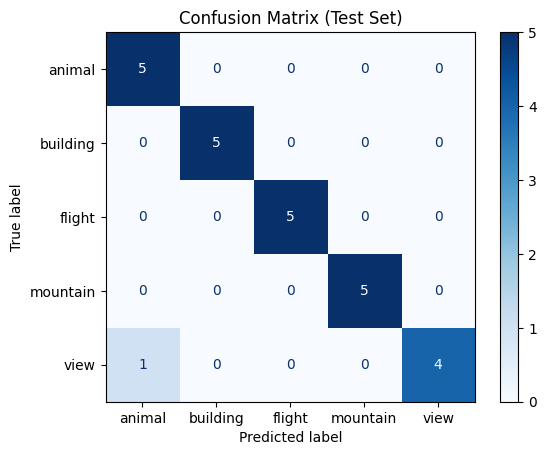


🔍 t-SNE 可视化特征分布...


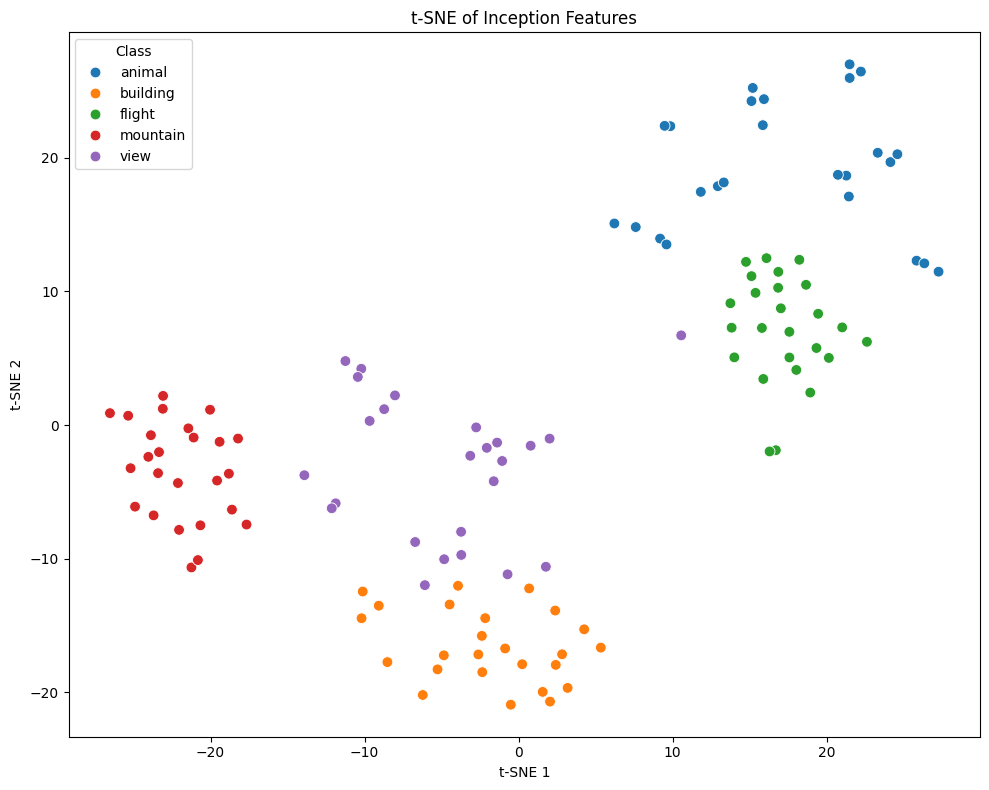

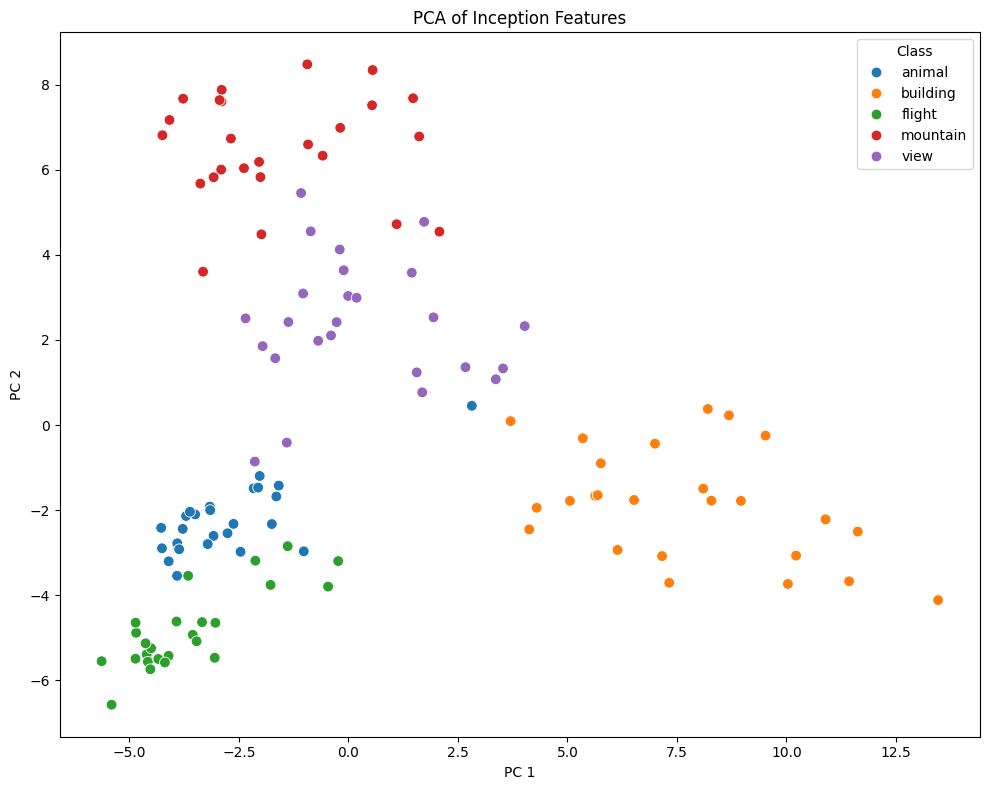

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()


print("\n🔍 t-SNE 可视化特征分布...")
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="tab10", s=60)
plt.title("t-SNE of Inception Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", s=60)
plt.title("PCA of Inception Features")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()


